<a href="https://www.kaggle.com/code/avikdas567/3lc-multi-vehicle-detection-challenge?scriptVersionId=315549506" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 3LC Multi Vehicle Detection: Data-Centric YOLOv8n Pipeline

This notebook implements a competition-compliant object detection pipeline for the 3LC Multi Vehicle Detection Challenge using a fixed-budget YOLOv8n architecture trained entirely from scratch.

The workflow focuses on data-centric optimization rather than architecture scaling, following the core philosophy of the competition.

---

## Pipeline Overview

The notebook combines:

- YOLOv8n training from scratch
- Conservative label sanitation
- Bounding-box consistency filtering
- Data quality validation
- Multi-class vehicle detection
- Submission-safe prediction formatting

Target classes: `truck`, `car`, `van`, `bus`

---

## Data-Centric Processing

Before training, the annotation set is cleaned using a lightweight QA pipeline that:

- removes malformed YOLO annotations
- filters invalid coordinates
- normalizes out-of-range boxes
- removes duplicate labels
- preserves valid annotations conservatively

This improves training stability while maintaining the original dataset structure.

---

## Training Strategy

The model is trained under the official competition constraints:

- YOLOv8n only
- pretrained weights disabled
- 640 px input resolution
- no ensembles
- no TTA
- no pseudo-labeling

The training recipe uses:

- AdamW optimization
- cosine learning-rate scheduling
- lightweight geometric augmentation
- mixed precision training
- fixed-budget inference

---

## Inference & Submission

Inference is performed directly on the hidden test split using the trained YOLOv8n checkpoint.

The notebook automatically:
- generates normalized YOLO predictions
- validates submission integrity
- verifies image alignment
- exports a competition-ready `submission.csv`

---

## Key Design Principles

- data quality over model scaling
- robust fixed-budget detection
- conservative annotation handling
- reproducible offline training
- competition-compliant inference pipeline

---

In [1]:
!pip install -q --upgrade pip setuptools wheel
!pip install -q 3lc-ultralytics umap-learn PyYAML tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
rfc3161-client 1.0.5 requires cryptography<47,>=43, but you have cryptography 47.0.0 which is incompatible.
sigstore 4.2.0 requires cryptography<47,>=42, but you have cryptography 47.0.0 which is incompatible.
sigstore 4.2.0 requires platformdirs~=4.2, but you have platformdirs 3.11.0 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, bu

In [2]:
import os
import gc
import re
import csv
import sys
import math
import time
import shutil
import random
from pathlib import Path

import yaml
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import pandas as pd

os.environ["WANDB_DISABLED"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

Torch: 2.10.0+cu128
CUDA available: True
GPU count: 2


In [3]:
# Paths

SOURCE_ROOT = Path("/kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter")
WORK_ROOT = Path("/kaggle/working/3lc_vehicle_work")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

assert SOURCE_ROOT.exists(), f"Starter folder not found: {SOURCE_ROOT}"

print("Source root:", SOURCE_ROOT)
print("Work root  :", WORK_ROOT)

Source root: /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter
Work root  : /kaggle/working/3lc_vehicle_work


In [4]:
small_files = [
    "README.md",
    "config.yaml",
    "dataset.yaml",
    "sample_submission.csv",
    "verify_setup.py",
    "register_tables.py",
    "train.py",
    "predict.py",
]

for name in small_files:
    src = SOURCE_ROOT / name
    dst = WORK_ROOT / name
    if src.exists():
        shutil.copy2(src, dst)

print("Copied starter metadata files.")
print(sorted(p.name for p in WORK_ROOT.iterdir() if p.is_file()))

Copied starter metadata files.
['README.md', 'config.yaml', 'dataset.yaml', 'predict.py', 'register_tables.py', 'sample_submission.csv', 'train.py', 'verify_setup.py']


Train images: 7852
Val images  : 982
Test images : 982

Train labels: {'images': 7852, 'empty': 0, 'invalid_lines': 0, 'boxes': 72273, 'class_counts': {0: 1226, 1: 59385, 2: 5558, 3: 6104}}
Val labels  : {'images': 982, 'empty': 2, 'invalid_lines': 0, 'boxes': 11615, 'class_counts': {0: 207, 1: 9470, 2: 954, 3: 984}}


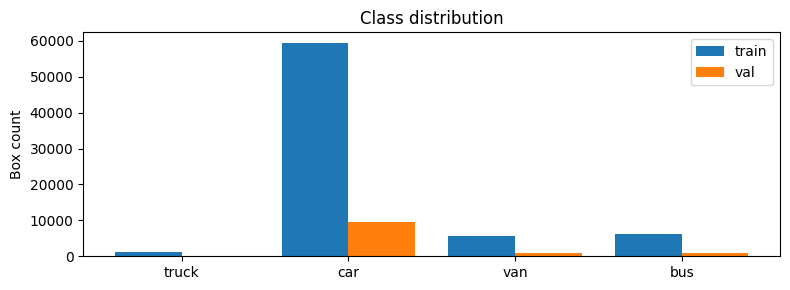

In [5]:
# Light data audit

CLASS_NAMES = ["truck", "car", "van", "bus"]
DATA_ROOT = SOURCE_ROOT / "data"

train_img_dir = DATA_ROOT / "train" / "images"
train_lab_dir = DATA_ROOT / "train" / "labels"
val_img_dir   = DATA_ROOT / "val" / "images"
val_lab_dir   = DATA_ROOT / "val" / "labels"
test_img_dir  = DATA_ROOT / "test" / "images"

def count_files(p: Path, suffixes=(".jpg", ".jpeg", ".png", ".bmp", ".webp")):
    return sum(1 for x in p.iterdir() if x.is_file() and x.suffix.lower() in suffixes)

def scan_labels(label_dir: Path):
    class_counts = {i: 0 for i in range(4)}
    n_images = 0
    n_empty = 0
    n_invalid = 0
    total_boxes = 0

    for f in sorted(label_dir.glob("*.txt")):
        n_images += 1
        if f.stat().st_size == 0:
            n_empty += 1
            continue

        valid_here = 0
        with f.open("r", encoding="utf-8") as fh:
            for line in fh:
                parts = line.strip().split()
                if len(parts) != 5:
                    n_invalid += 1
                    continue
                try:
                    cls = int(float(parts[0]))
                    vals = [float(x) for x in parts[1:]]
                except Exception:
                    n_invalid += 1
                    continue
                if cls not in class_counts:
                    n_invalid += 1
                    continue
                if any(np.isnan(v) or np.isinf(v) for v in vals):
                    n_invalid += 1
                    continue
                valid_here += 1
                class_counts[cls] += 1
        total_boxes += valid_here

    return {
        "images": n_images,
        "empty": n_empty,
        "invalid_lines": n_invalid,
        "boxes": total_boxes,
        "class_counts": class_counts,
    }

train_stats = scan_labels(train_lab_dir)
val_stats = scan_labels(val_lab_dir)

print("Train images:", count_files(train_img_dir))
print("Val images  :", count_files(val_img_dir))
print("Test images :", count_files(test_img_dir))
print()

print("Train labels:", train_stats)
print("Val labels  :", val_stats)

fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(len(CLASS_NAMES))
train_counts = [train_stats["class_counts"][i] for i in range(4)]
val_counts = [val_stats["class_counts"][i] for i in range(4)]

ax.bar(x - 0.2, train_counts, width=0.4, label="train")
ax.bar(x + 0.2, val_counts, width=0.4, label="val")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("Box count")
ax.set_title("Class distribution")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Conservative label sanitation

CLEAN_ROOT = WORK_ROOT / "clean_data"
if CLEAN_ROOT.exists():
    shutil.rmtree(CLEAN_ROOT)

def _safe_link_dir(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src, dst, target_is_directory=True)
    except Exception:
        if not dst.exists():
            shutil.copytree(src, dst)

def _sanitize_label_file(src: Path, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    cleaned = []
    seen = set()

    if not src.exists() or src.stat().st_size == 0:
        dst.write_text("", encoding="utf-8")
        return 0, 0

    kept = 0
    dropped = 0
    with src.open("r", encoding="utf-8") as fh:
        for line in fh:
            parts = line.strip().split()
            if len(parts) != 5:
                dropped += 1
                continue

            try:
                cls = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:])
            except Exception:
                dropped += 1
                continue

            if cls not in (0, 1, 2, 3):
                dropped += 1
                continue

            if not np.isfinite([x, y, w, h]).all():
                dropped += 1
                continue

            # Clamp to the normalized YOLO range.
            x = min(1.0, max(0.0, x))
            y = min(1.0, max(0.0, y))
            w = min(1.0, max(0.0, w))
            h = min(1.0, max(0.0, h))

            if w <= 0.0 or h <= 0.0:
                dropped += 1
                continue

            # Remove exact duplicates after rounding.
            key = (cls, round(x, 6), round(y, 6), round(w, 6), round(h, 6))
            if key in seen:
                dropped += 1
                continue
            seen.add(key)

            cleaned.append(f"{cls} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
            kept += 1

    dst.write_text("\n".join(cleaned) + ("\n" if cleaned else ""), encoding="utf-8")
    return kept, dropped

print("Building clean dataset tree...")

for split in ["train", "val", "test"]:
    split_root = CLEAN_ROOT / split
    split_root.mkdir(parents=True, exist_ok=True)

    _safe_link_dir(DATA_ROOT / split / "images", split_root / "images")

    if split in ("train", "val"):
        (split_root / "labels").mkdir(parents=True, exist_ok=True)
        src_labels = DATA_ROOT / split / "labels"
        total_kept = 0
        total_dropped = 0
        for lab in tqdm(sorted(src_labels.glob("*.txt")), desc=f"Sanitizing {split} labels"):
            kept, dropped = _sanitize_label_file(lab, split_root / "labels" / lab.name)
            total_kept += kept
            total_dropped += dropped
        print(f"{split}: kept {total_kept} boxes, dropped {total_dropped} malformed/duplicate boxes")

print("Clean dataset ready:", CLEAN_ROOT)

Building clean dataset tree...


Sanitizing train labels:   0%|          | 0/7852 [00:00<?, ?it/s]

train: kept 72273 boxes, dropped 0 malformed/duplicate boxes


Sanitizing val labels:   0%|          | 0/982 [00:00<?, ?it/s]

val: kept 11615 boxes, dropped 0 malformed/duplicate boxes
Clean dataset ready: /kaggle/working/3lc_vehicle_work/clean_data


In [7]:
# Build a local dataset.yaml for ultralytics

dataset_yaml = WORK_ROOT / "dataset_kaggle.yaml"

dataset_cfg = {
    "path": str(CLEAN_ROOT),
    "train": str(CLEAN_ROOT / "train" / "images"),
    "val": str(CLEAN_ROOT / "val" / "images"),
    "test": str(CLEAN_ROOT / "test" / "images"),
    "nc": 4,
    "names": CLASS_NAMES,
}

with dataset_yaml.open("w", encoding="utf-8") as f:
    yaml.safe_dump(dataset_cfg, f, sort_keys=False)

print(dataset_yaml.read_text())

path: /kaggle/working/3lc_vehicle_work/clean_data
train: /kaggle/working/3lc_vehicle_work/clean_data/train/images
val: /kaggle/working/3lc_vehicle_work/clean_data/val/images
test: /kaggle/working/3lc_vehicle_work/clean_data/test/images
nc: 4
names:
- truck
- car
- van
- bus



In [8]:
# Load YOLO implementation

YOLO = None
backend = None

try:
    from ultralytics import YOLO as _YOLO
    YOLO = _YOLO
    backend = "ultralytics"
except Exception:
    try:
        from tlc_ultralytics import YOLO as _YOLO
        YOLO = _YOLO
        backend = "tlc_ultralytics"
    except Exception as e:
        raise ImportError(
            "Neither `ultralytics` nor `tlc_ultralytics` is available in this notebook environment."
        ) from e

print("Using backend:", backend)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using backend: ultralytics


In [9]:
# Training configuration

if torch.cuda.is_available() and torch.cuda.device_count() >= 2:
    DEVICE = "0,1"
    BATCH = 32
else:
    DEVICE = 0 if torch.cuda.is_available() else "cpu"
    BATCH = 16 if torch.cuda.is_available() else 8

EPOCHS = 6
IMGSZ = 640
RUN_NAME = "yolov8n_from_scratch_fixed_budget"
PROJECT_DIR = WORK_ROOT / "runs"

print("DEVICE:", DEVICE)
print("BATCH :", BATCH)
print("EPOCHS:", EPOCHS)
print("IMGSZ :", IMGSZ)
print("PROJECT DIR:", PROJECT_DIR)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = YOLO("yolov8n.yaml")  # from-scratch architecture only

DEVICE: 0,1
BATCH : 32
EPOCHS: 6
IMGSZ : 640
PROJECT DIR: /kaggle/working/3lc_vehicle_work/runs


In [10]:
# Train from scratch

train_kwargs = dict(
    data=str(dataset_yaml),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    workers=min(4, max(1, (os.cpu_count() or 2) - 1)),
    project=str(PROJECT_DIR),
    name=RUN_NAME,
    exist_ok=True,
    pretrained=False,
    optimizer="AdamW",
    lr0=0.003,
    lrf=0.01,
    cos_lr=True,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=0.5,
    patience=2,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0.0,
    close_mosaic=1,
    fliplr=0.5,
    translate=0.1,
    scale=0.5,
    cache=False,
    amp=True,
    verbose=True,
    seed=SEED,
)

print("Training kwargs:")
for k, v in train_kwargs.items():
    if k not in {"data"}:
        print(f"  {k}: {v}")

t0 = time.time()
train_results = model.train(**train_kwargs)
t1 = time.time()

print(f"Training finished in {(t1 - t0)/60:.2f} min")

Training kwargs:
  epochs: 6
  imgsz: 640
  batch: 32
  device: 0,1
  workers: 3
  project: /kaggle/working/3lc_vehicle_work/runs
  name: yolov8n_from_scratch_fixed_budget
  exist_ok: True
  pretrained: False
  optimizer: AdamW
  lr0: 0.003
  lrf: 0.01
  cos_lr: True
  momentum: 0.937
  weight_decay: 0.0005
  warmup_epochs: 0.5
  patience: 2
  mosaic: 1.0
  mixup: 0.05
  copy_paste: 0.0
  close_mosaic: 1
  fliplr: 0.5
  translate: 0.1
  scale: 0.5
  cache: False
  amp: True
  verbose: True
  seed: 42
New https://pypi.org/project/ultralytics/8.4.45 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=1, cls=0.5, compile=False, conf=None, copy_paste=0.0,

Error.  nthreads cannot be larger than environment variable "NUMEXPR_MAX_THREADS" (3)

Overriding model.yaml nc=80 with nc=4
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...
AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.9±0.9 MB/s, size: 58.6 KB)
train: Scanning /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter/data/train/labels... 7852 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7852/7852 221.4it/s 35.5s
WARNING ⚠️ train: Cache directory /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter/data/train is not writable, cache not saved.
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 1.1±1.3 ms, read: 7.0±2.2 MB/s, size: 56.6 KB)
val: Scanning /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter

In [11]:
# Optional validation pass on the cleaned validation split

best_weights = PROJECT_DIR / RUN_NAME / "weights" / "best.pt"
print("Best weights:", best_weights)

if best_weights.exists():
    val_model = YOLO(str(best_weights))
    val_metrics = val_model.val(
        data=str(dataset_yaml),
        split="val",
        imgsz=IMGSZ,
        device=DEVICE,
        conf=0.001,
        iou=0.65,
        verbose=False,
    )
    print(val_metrics)
else:
    print("Best weights not found yet.")

Best weights: /kaggle/working/3lc_vehicle_work/runs/yolov8n_from_scratch_fixed_budget/weights/best.pt
Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                      CUDA:1 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 44.8±4.1 MB/s, size: 53.9 KB)
val: Scanning /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter/data/val/labels... 982 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 982/982 437.8it/s 2.2s
WARNING ⚠️ val: Cache directory /kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter/data/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 3% ──────────── 2/62 1.7it/s 1.1s<34.7s

Exception in thread Thread-13 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    self.args = args
    ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 6% ╸─────────── 4/62 1.4it/s 3.1s<41.3s

Exception in thread Thread-17 (plot_images):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/utils/plotting.py", line 850, in plot_images
    annotator.im.save(fname)  # save
    ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/Image.py", line 2588, in save
    See :py:meth:`~PIL.Image.Image.tell`.
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py", line 813, in _save
    ImageFile._save(im, fp, [("jpeg", (0, 0) + im.size, 0, rawmode)], bufsize)
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 646, in _save
    self.args = args
    ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/PIL/ImageFile.py", line 664, in _encode_

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 5.4it/s 11.5s
                   all        982      11615      0.866      0.685      0.793        0.6
Speed: 0.9ms preprocess, 4.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a9bfafe0050>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022

In [12]:
# Inference on test images and submission creation

sample_sub = pd.read_csv(SOURCE_ROOT / "sample_submission.csv")
test_image_dir = DATA_ROOT / "test" / "images"

# Support several common image extensions.
def find_image_by_stem(stem: str) -> Path | None:
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
        p = test_image_dir / f"{stem}{ext}"
        if p.exists():
            return p
    # Fallback: glob by prefix
    matches = list(test_image_dir.glob(stem + ".*"))
    return matches[0] if matches else None

if not best_weights.exists():
    raise FileNotFoundError(f"Missing trained weights: {best_weights}")

pred_model = YOLO(str(best_weights))

image_paths = []
missing = []
for stem in sample_sub["image_id"].astype(str).tolist():
    p = find_image_by_stem(stem)
    if p is None:
        missing.append(stem)
    else:
        image_paths.append(p)

if missing:
    print("WARNING: missing test images:", missing[:10], "..." if len(missing) > 10 else "")
print("Found test images:", len(image_paths))

def result_to_prediction_string(result) -> str:
    boxes = getattr(result, "boxes", None)
    if boxes is None or len(boxes) == 0:
        return "no box"

    xywhn = boxes.xywhn.cpu().numpy()
    cls = boxes.cls.cpu().numpy().astype(int)
    conf = boxes.conf.cpu().numpy()

    order = np.argsort(-conf)
    parts = []
    for i in order:
        c = int(cls[i])
        cf = float(conf[i])
        x, y, w, h = [float(v) for v in xywhn[i]]

        # Clamp to [0,1] for safety.
        x = min(1.0, max(0.0, x))
        y = min(1.0, max(0.0, y))
        w = min(1.0, max(0.0, w))
        h = min(1.0, max(0.0, h))

        parts.extend([
            str(c),
            f"{cf:.6f}",
            f"{x:.6f}",
            f"{y:.6f}",
            f"{w:.6f}",
            f"{h:.6f}",
        ])
    return " ".join(parts)

PRED_CONF = 0.001
PRED_IOU = 0.65
PRED_MAX_DET = 300
PRED_BATCH = max(1, min(BATCH, 16))

pred_map = {}

t0 = time.time()
for i in tqdm(range(0, len(image_paths), PRED_BATCH), desc="Predicting"):
    chunk = image_paths[i:i+PRED_BATCH]
    results = pred_model.predict(
        source=[str(p) for p in chunk],
        imgsz=IMGSZ,
        conf=PRED_CONF,
        iou=PRED_IOU,
        max_det=PRED_MAX_DET,
        device=DEVICE,
        verbose=False,
    )
    for path, result in zip(chunk, results):
        pred_map[path.stem] = result_to_prediction_string(result)
t1 = time.time()

print(f"Inference finished in {(t1 - t0):.1f} sec")

Found test images: 982


Predicting:   0%|          | 0/62 [00:00<?, ?it/s]

Inference finished in 21.5 sec


In [13]:
# Build submission.csv in the required format and validate it

submission = sample_sub.copy()
submission["prediction_string"] = submission["image_id"].map(pred_map).fillna("no box")

# Hard validation
assert list(submission.columns) == ["id", "image_id", "prediction_string"]
assert len(submission) == len(sample_sub)
assert submission["image_id"].astype(str).tolist() == sample_sub["image_id"].astype(str).tolist()

# Basic parse check
def is_valid_prediction_string(s: str) -> bool:
    if s == "no box":
        return True
    tokens = s.split()
    return len(tokens) % 6 == 0

assert submission["prediction_string"].map(is_valid_prediction_string).all()

out_path = WORK_ROOT / "submission.csv"
submission.to_csv(out_path, index=False)

print("Saved:", out_path)
display(submission.head(10))
print("Rows:", len(submission))
print("Non-empty predictions:", (submission["prediction_string"] != "no box").sum())

Saved: /kaggle/working/3lc_vehicle_work/submission.csv


,id,image_id,prediction_string
0,0,MVI_20011_img00001_jpg.rf.21eb8e9f48c70c8b2186...,1 0.855513 0.695428 0.847409 0.169100 0.305182...
1,1,MVI_20011_img00019_jpg.rf.4105d8df0fc287df67ff...,1 0.914886 0.882582 0.376298 0.097461 0.131718...
2,2,MVI_20011_img00086_jpg.rf.cbbdb64f1942a10e4280...,1 0.906102 0.623620 0.575368 0.101030 0.210493...
3,3,MVI_20011_img00206_jpg.rf.c97e5a0655ebeb4a217d...,1 0.907859 0.633208 0.399081 0.075171 0.137902...
4,4,MVI_20011_img00226_jpg.rf.da8e14aeda4d153e2a7c...,1 0.901372 0.672829 0.618479 0.113855 0.236487...
5,5,MVI_20011_img00339_jpg.rf.334fca1e6ced0862e76d...,1 0.888286 0.618739 0.693170 0.131330 0.289592...
6,6,MVI_20011_img00348_jpg.rf.51b7a70bcc924548508e...,1 0.892871 0.718376 0.334286 0.081253 0.144617...
7,7,MVI_20011_img00449_jpg.rf.908bda312e93dda38d27...,1 0.854385 0.824062 0.275126 0.076618 0.112100...
8,8,MVI_20011_img00483_jpg.rf.69fe7a1d0a566584acf4...,1 0.916747 0.907732 0.380545 0.102616 0.130139...
9,9,MVI_20011_img00591_jpg.rf.f3106ce093ed40da6b48...,1 0.887157 0.537134 0.230881 0.052159 0.087835...


Rows: 982
Non-empty predictions: 982


In [14]:
sub = pd.read_csv("/kaggle/working/3lc_vehicle_work/submission.csv")
sample = pd.read_csv("/kaggle/input/competitions/3-lc-multi-vehicle-detection-challenge/competition_starter/sample_submission.csv")

print(sub.columns.tolist())
print(len(sub), len(sample))
print((sub["image_id"] == sample["image_id"]).all())
display(sub)

['id', 'image_id', 'prediction_string']
982 982
True


,id,image_id,prediction_string
0,0,MVI_20011_img00001_jpg.rf.21eb8e9f48c70c8b2186...,1 0.855513 0.695428 0.847409 0.169100 0.305182...
1,1,MVI_20011_img00019_jpg.rf.4105d8df0fc287df67ff...,1 0.914886 0.882582 0.376298 0.097461 0.131718...
2,2,MVI_20011_img00086_jpg.rf.cbbdb64f1942a10e4280...,1 0.906102 0.623620 0.575368 0.101030 0.210493...
3,3,MVI_20011_img00206_jpg.rf.c97e5a0655ebeb4a217d...,1 0.907859 0.633208 0.399081 0.075171 0.137902...
4,4,MVI_20011_img00226_jpg.rf.da8e14aeda4d153e2a7c...,1 0.901372 0.672829 0.618479 0.113855 0.236487...
...,...,...,...
977,977,MVI_63563_img01070_jpg.rf.68afde8d1acd1765324f...,1 0.904405 0.636865 0.428894 0.161673 0.147124...
978,978,MVI_63563_img01129_jpg.rf.a5331c3617a8bb3f0b2e...,1 0.900306 0.219249 0.367885 0.153556 0.134463...
979,979,MVI_63563_img01130_jpg.rf.e46ed3190c06ad60c6d4...,1 0.899510 0.176590 0.280066 0.119146 0.108749...
980,980,MVI_63563_img01334_jpg.rf.4c03b363dea16611d37d...,1 0.919613 0.862479 0.238519 0.122281 0.111964...
